<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/Week2Day1_Butina_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 44.0 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdFingerprintGenerator, AllChem, DataStructs
import pandas as pd
import numpy as np
from rdkit.Chem import MolStandardize
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Cluster import Butina
from rdkit import DataStructs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_clean = pd.read_csv('/content/drive/MyDrive/drugproj/df_thrombin_clean.csv')
print(df_clean.shape)
df_clean.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3477, 10)


,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value,canonical_smiles_std,is_pains
0,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,CHEMBL369583,=,=,nM,1.30,nM,1.300,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,False
1,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,CHEMBL176744,=,=,nM,2.00,nM,2.000,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,False
2,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,CHEMBL367476,=,=,nM,3.30,nM,3.300,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,False
3,CC1CCN(C(=O)[C@H](Cc2cccc(C(=N)N)c2)NS(=O)(=O)...,CHEMBL145741,=,=,nM,1999.86,NaN,5.699,CC1CCN(C(=O)C(Cc2cccc(C(=N)N)c2)NS(=O)(=O)c2c(...,False
4,COC(=O)[C@H]1Cc2ccccc2CN1C(=O)[C@H](Cc1cccc(C(...,CHEMBL145795,=,=,nM,26977.39,NaN,4.569,COC(=O)C1Cc2ccccc2CN1C(=O)C(Cc1cccc(C(=N)N)c1)...,False


In [ ]:
#Morgan fingerprints on the standardized SMILES.

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles_std']]
valid_mask = [m is not None for m in mols]
df_clean = df_clean[valid_mask].reset_index(drop=True)
mols = [m for m in mols if m is not None]

fps = [mfpgen.GetFingerprint(m) for m in mols]
print(f"Generated {len(fps)} fingerprints")

Generated 3477 fingerprints


In [ ]:
#Pairwise distance matrix.
def tanimoto_distance_matrix(fps):
    dists = []
    for i in range(1, len(fps)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - s for s in sims])
    return dists

dists = tanimoto_distance_matrix(fps)
print(f"Matrix length: {len(dists)} (expected {len(fps)*(len(fps)-1)//2})")

Matrix length: 6043026 (expected 6043026)


In [ ]:
import pickle
with open('/content/drive/MyDrive/drugproj/dists.pkl', 'wb') as f:
    pickle.dump(dists, f)

In [ ]:
#Running Butina
cutoff = 0.35  # distance cutoff. Tanimoto threshold = 1 - cutoff = 0.65
clusters = Butina.ClusterData(dists, len(fps), cutoff, isDistData=True)
print(f"Number of clusters: {len(clusters)}")

Number of clusters: 656


Largest cluster: 84 compounds
Singletons (size 1): 279
Clusters with >10 compounds: 81


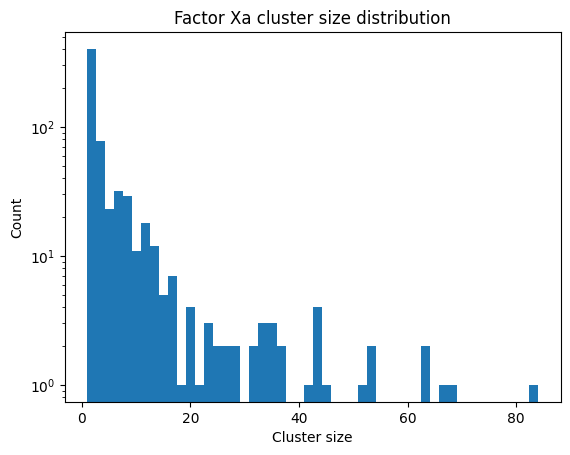

In [ ]:
#Size Distribution
cluster_sizes = [len(c) for c in clusters]
print(f"Largest cluster: {cluster_sizes[0]} compounds")
print(f"Singletons (size 1): {sum(1 for s in cluster_sizes if s == 1)}")
print(f"Clusters with >10 compounds: {sum(1 for s in cluster_sizes if s > 10)}")

import matplotlib.pyplot as plt
plt.hist(cluster_sizes, bins=50)
plt.xlabel('Cluster size')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Factor Xa cluster size distribution')
plt.show()

In [ ]:
# 1. Create the missing 'pKi' column from your standard_value column
pKi_values = []
for val in df_clean['standard_value']:
    # Convert text strings to floats just in case, and safeguard against 0
    val_float = float(val)
    if val_float <= 0:
        pKi_values.append(0.0)
    else:
        pKi = 9.0 - np.log10(val_float)
        pKi_values.append(pKi)

# Add it permanently to your table
df_clean['pKi'] = pKi_values
df_clean.head()

,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value,canonical_smiles_std,is_pains,pKi
0,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,CHEMBL369583,=,=,nM,1.30,nM,1.300,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,False,8.886057
1,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,CHEMBL176744,=,=,nM,2.00,nM,2.000,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,False,8.698970
2,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,CHEMBL367476,=,=,nM,3.30,nM,3.300,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,False,8.481486
3,CC1CCN(C(=O)[C@H](Cc2cccc(C(=N)N)c2)NS(=O)(=O)...,CHEMBL145741,=,=,nM,1999.86,NaN,5.699,CC1CCN(C(=O)C(Cc2cccc(C(=N)N)c2)NS(=O)(=O)c2c(...,False,5.699000
4,COC(=O)[C@H]1Cc2ccccc2CN1C(=O)[C@H](Cc1cccc(C(...,CHEMBL145795,=,=,nM,26977.39,NaN,4.569,COC(=O)C1Cc2ccccc2CN1C(=O)C(Cc1cccc(C(=N)N)c1)...,False,4.569000


Largest cluster has 84 compounds


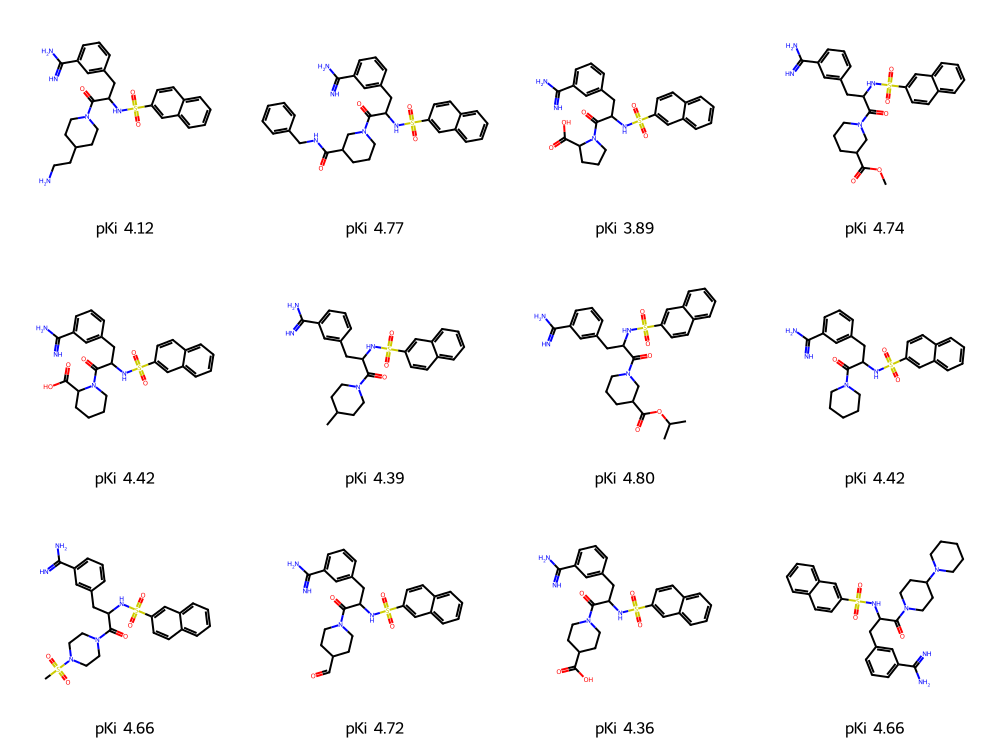

In [ ]:
#Biggest Cluster
from rdkit.Chem import Draw

biggest = clusters[0]
print(f"Largest cluster has {len(biggest)} compounds")

top_mols = [mols[i] for i in biggest[:12]]
img = Draw.MolsToGridImage(
    top_mols, molsPerRow=4, subImgSize=(250, 250),
    legends=[f"pKi {df_clean['pKi'].iloc[i]:.2f}" for i in biggest[:12]]
)
img


In [ ]:
df_clean['cluster_id'] = -1
for cluster_idx, cluster in enumerate(clusters):
    for mol_idx in cluster:
        df_clean.at[mol_idx, 'cluster_id'] = cluster_idx

df_clean.to_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv', index=False)